# Kernel K-Means

## Introduction

Kernel K-Means is an extension of the traditional K-Means clustering algorithm.

Ordinary K-Means works well when clusters are approximately spherical and linearly separable in the original feature space.

However, many real-world datasets contain non-linear cluster structures.

Examples include:

- Concentric circles
- Two moons
- Spiral-shaped clusters
- Complex image or pattern data

Kernel K-Means solves this problem by implicitly mapping the original data into a higher-dimensional feature space using a kernel function.

The clustering is then performed in this transformed feature space.

### Main idea

Instead of directly clustering:

    X

Kernel K-Means conceptually clusters:

    φ(X)

where φ is a possibly high-dimensional feature mapping.

Using the kernel trick, we do not need to explicitly calculate φ(X).

We can work directly with the kernel matrix:

    K(x_i, x_j) = φ(x_i) · φ(x_j)

This allows K-Means to discover non-linear cluster structures.

## Learning Objectives

After completing this notebook, we should understand:

1. Why ordinary K-Means struggles with non-linear clusters.
2. The basic idea behind Kernel K-Means.
3. How feature mapping helps clustering.
4. What the kernel trick means.
5. How a kernel matrix is constructed.
6. How distance is calculated in kernel space.
7. The mathematical objective of Kernel K-Means.
8. How Kernel K-Means works step by step.
9. How to implement Kernel K-Means from scratch.
10. How the RBF kernel affects clustering.
11. The difference between ordinary K-Means and Kernel K-Means.
12. The advantages and limitations of Kernel K-Means.

# 1. Why Do We Need Kernel K-Means?

Ordinary K-Means assumes that clusters can be represented reasonably well using distances in the original feature space.

For example, consider two concentric circles.

The inner circle belongs to one cluster and the outer circle belongs to another cluster.

There is no straight-line boundary that separates these two clusters.

Therefore, ordinary K-Means has difficulty identifying the correct cluster structure.

### Example

Imagine:

    Outer Circle → Cluster 1

        ○ ○ ○ ○ ○
      ○           ○
     ○    ● ● ●    ○
      ○           ○
        ○ ○ ○ ○ ○

    Inner Circle → Cluster 2

The two clusters are separated by a non-linear boundary.

Kernel K-Means addresses this by transforming the data into another feature space where the clusters may become easier to separate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.cluster import KMeans

# 2. Create a Non-Linear Dataset

We will create a dataset containing two concentric circles.

This dataset is useful because it clearly demonstrates the limitation of ordinary K-Means.

In [2]:
X, y = make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.05,
    random_state=42
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (500, 2)
Shape of y: (500,)


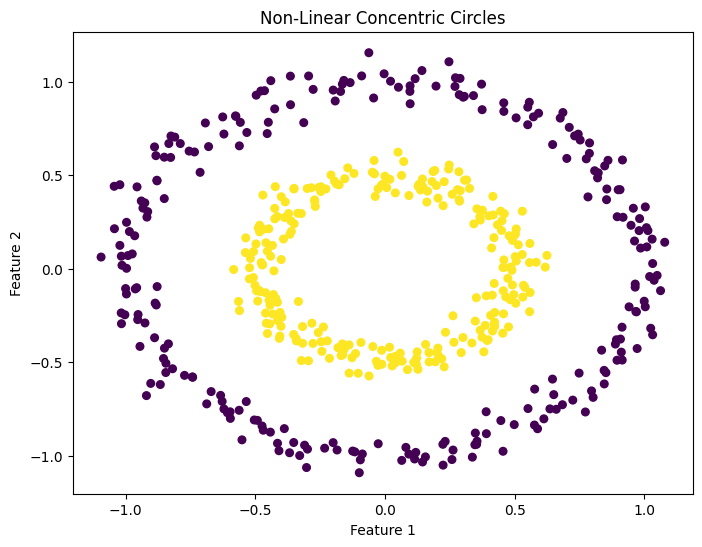

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
    s=30
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Non-Linear Concentric Circles")

plt.show()

# 3. Ordinary K-Means

Before understanding Kernel K-Means, we should understand the limitation of ordinary K-Means.

K-Means attempts to divide the data into K clusters by minimizing the distance between each point and its assigned cluster centroid.

The algorithm works directly in the original feature space.

For our dataset:

    X ∈ R²

Therefore, K-Means works directly with the two original features.

Let's see what happens.

In [4]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

print("Cluster centers:")
print(kmeans.cluster_centers_)

Cluster centers:
[[ 0.46601929  0.05172578]
 [-0.48745805 -0.05237367]]


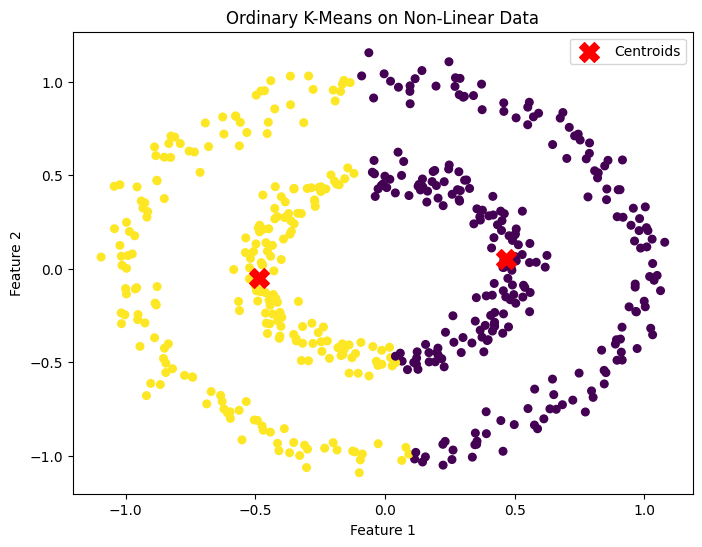

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=30
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    color="red",
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Ordinary K-Means on Non-Linear Data")
plt.legend()

plt.show()

## Observation

Ordinary K-Means does not naturally understand the circular structure.

The reason is that K-Means uses Euclidean distance in the original feature space.

It tries to create clusters around centroids.

For concentric circles, however, the natural cluster boundary is circular rather than based on distance from two ordinary centroids.

This motivates the use of Kernel K-Means.

# 4. Review of Ordinary K-Means

Suppose we have:

    n data points

    x₁, x₂, ..., xₙ

and want:

    K clusters

Each cluster has a centroid:

    μ₁, μ₂, ..., μₖ

For every data point xᵢ, K-Means assigns it to the nearest centroid.

The assignment is:

    cᵢ = argminₖ ||xᵢ - μₖ||²

The objective function is:

    J = Σᵢ ||xᵢ - μ_cᵢ||²

where:

    cᵢ = cluster assigned to xᵢ

The centroid of cluster Cₖ is:

    μₖ = (1 / |Cₖ|) Σ_{xᵢ ∈ Cₖ} xᵢ

The important point is that these calculations happen in the original feature space.

# 5. Feature Mapping

Kernel K-Means introduces the idea of a feature mapping.

Suppose the original data point is:

    x

We map it to another feature space:

    φ(x)

For example:

    x → φ(x)

The new feature space may have a much higher dimension.

The purpose is to make complex structures easier to cluster.

### Important idea

The transformation may make a non-linear structure in the original space look simpler in the transformed space.

Conceptually:

    Original Space
          ↓
      φ(x)
          ↓
    Feature Space
          ↓
     K-Means-like
      clustering

# 6. The Problem with Explicit Feature Mapping

Suppose φ(x) maps a two-dimensional point into a feature space containing hundreds, thousands, or even infinitely many dimensions.

Explicitly calculating:

    φ(x)

could be computationally expensive or even impossible.

Kernel methods solve this problem.

Instead of calculating φ(x) directly, we calculate the similarity between two transformed points:

    φ(xᵢ) · φ(xⱼ)

This is provided by a kernel function:

    K(xᵢ, xⱼ) = φ(xᵢ) · φ(xⱼ)

This idea is called the:

## Kernel Trick

The kernel trick allows us to perform calculations in a high-dimensional feature space without explicitly constructing that feature space.

# 7. Common Kernel Functions

Several kernel functions can be used.

## 1. Linear Kernel

    K(x, z) = x · z

This corresponds to using the original feature space.

---

## 2. Polynomial Kernel

    K(x, z) = (x · z + c)^d

where:

    d = polynomial degree
    c = constant

---

## 3. RBF / Gaussian Kernel

The RBF kernel is:

    K(x, z) =
    exp(-γ ||x - z||²)

where:

    γ = gamma parameter

The RBF kernel measures similarity based on distance.

If two points are close:

    K(x, z) ≈ 1

If two points are far apart:

    K(x, z) ≈ 0

The RBF kernel is particularly useful for non-linear structures.

# 8. Kernel Matrix

For n data points, the kernel matrix is an n × n matrix.

It is defined as:

    Kᵢⱼ = K(xᵢ, xⱼ)

Therefore:

    K =
    [ K(x₁,x₁)  K(x₁,x₂)  ... ]
    [ K(x₂,x₁)  K(x₂,x₂)  ... ]
    [    ...        ...     ... ]

For an RBF kernel:

    Kᵢⱼ =
    exp(-γ ||xᵢ - xⱼ||²)

The kernel matrix contains the pairwise similarities between all data points.

Kernel K-Means can perform clustering using this matrix without explicitly calculating φ(x).

In [6]:
def rbf_kernel(X, gamma=1.0):
    squared_distances = (
        np.sum(X**2, axis=1).reshape(-1, 1)
        + np.sum(X**2, axis=1).reshape(1, -1)
        - 2 * X @ X.T
    )

    K = np.exp(-gamma * squared_distances)

    return K

In [7]:
K = rbf_kernel(X, gamma=5.0)

print("Kernel matrix shape:", K.shape)
print("First 5 × 5 values:")
print(K[:5, :5])

Kernel matrix shape: (500, 500)
First 5 × 5 values:
[[1.00000000e+00 3.09304604e-02 8.34604279e-01 1.88716510e-02
  2.52832252e-01]
 [3.09304604e-02 1.00000000e+00 5.86418559e-03 3.75260151e-07
  5.17377109e-02]
 [8.34604279e-01 5.86418559e-03 1.00000000e+00 8.24237326e-02
  1.02477437e-01]
 [1.88716510e-02 3.75260151e-07 8.24237326e-02 1.00000000e+00
  3.49155867e-04]
 [2.52832252e-01 5.17377109e-02 1.02477437e-01 3.49155867e-04
  1.00000000e+00]]


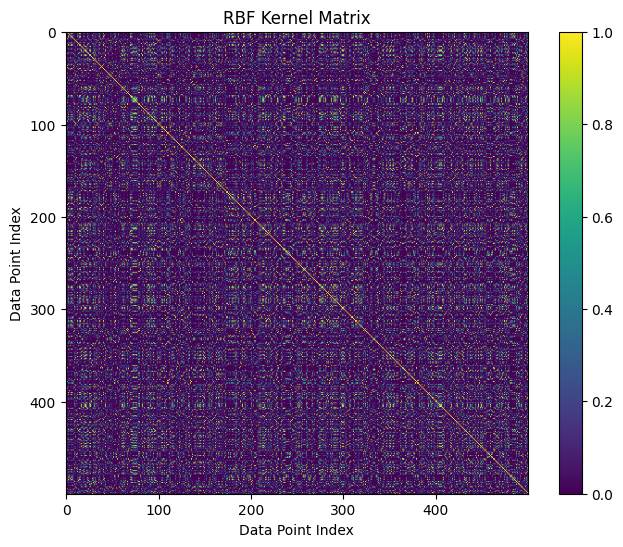

In [8]:
plt.figure(figsize=(8, 6))

plt.imshow(K)

plt.xlabel("Data Point Index")
plt.ylabel("Data Point Index")
plt.title("RBF Kernel Matrix")

plt.colorbar()

plt.show()

# 9. Distance in Kernel Space

This is one of the most important mathematical ideas in Kernel K-Means.

Suppose:

    φ(xᵢ)

and:

    φ(xⱼ)

are two transformed points.

Their squared Euclidean distance in feature space is:

    ||φ(xᵢ) - φ(xⱼ)||²

Expanding:

    = φ(xᵢ)·φ(xᵢ)
      + φ(xⱼ)·φ(xⱼ)
      - 2φ(xᵢ)·φ(xⱼ)

Using the kernel function:

    K(xᵢ,xᵢ)
    + K(xⱼ,xⱼ)
    - 2K(xᵢ,xⱼ)

Therefore:

    ||φ(xᵢ) - φ(xⱼ)||²
    =
    Kᵢᵢ + Kⱼⱼ - 2Kᵢⱼ

This is the key reason Kernel K-Means can work without explicitly calculating φ(x).

# 10. Kernel K-Means Objective

Ordinary K-Means minimizes:

    Σᵢ ||xᵢ - μ_cᵢ||²

Kernel K-Means performs the equivalent clustering in feature space:

    Σᵢ ||φ(xᵢ) - μ_cᵢ^φ||²

where:

    μ_cᵢ^φ

is the centroid in feature space.

The important problem is that we do not explicitly know φ(x).

Fortunately, the distance from a point to a cluster centroid can be expressed entirely using the kernel matrix.

For a point xᵢ assigned to cluster C:

    D(i,C)
    =
    Kᵢᵢ
    - (2 / |C|) Σⱼ∈C Kᵢⱼ
    + (1 / |C|²) Σⱼ∈C Σₗ∈C Kⱼₗ

This equation allows Kernel K-Means to calculate the distance to a cluster centroid using only kernel values.

# 11. Kernel K-Means Algorithm

The algorithm follows the same general iterative idea as K-Means.

### Step 1 — Choose K

Select the number of clusters.

### Step 2 — Compute the Kernel Matrix

Calculate:

    Kᵢⱼ = K(xᵢ,xⱼ)

### Step 3 — Initialize Cluster Assignments

Assign every data point to an initial cluster.

### Step 4 — Calculate Distance to Each Cluster

For every point, calculate its kernel-space distance to each cluster.

### Step 5 — Reassign Points

Assign each point to the cluster with the smallest kernel-space distance.

### Step 6 — Repeat

Repeat the distance calculation and reassignment until:

- assignments stop changing, or
- the maximum number of iterations is reached.

### Important Difference

Ordinary K-Means explicitly stores centroids.

Kernel K-Means does not need to explicitly represent centroids in the high-dimensional feature space.

Instead, it represents the required calculations using the kernel matrix.

# 12. Implement Kernel K-Means From Scratch

We will now implement Kernel K-Means using NumPy.

Our implementation will:

1. Calculate the kernel matrix.
2. Randomly initialize cluster assignments.
3. Calculate kernel-space distances.
4. Reassign points.
5. Repeat until convergence.

In [9]:
def kernel_kmeans(
    X,
    n_clusters=2,
    gamma=5.0,
    max_iter=100,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    n_samples = X.shape[0]

    # Step 1: Compute kernel matrix
    K = rbf_kernel(X, gamma=gamma)

    # Step 2: Random initialization
    labels = rng.integers(
        low=0,
        high=n_clusters,
        size=n_samples
    )

    for iteration in range(max_iter):

        old_labels = labels.copy()

        distances = np.zeros(
            (n_samples, n_clusters)
        )

        # Step 3: Calculate distance to every cluster
        for cluster in range(n_clusters):

            cluster_indices = np.where(
                labels == cluster
            )[0]

            # Avoid empty clusters
            if len(cluster_indices) == 0:
                distances[:, cluster] = np.inf
                continue

            n_cluster = len(cluster_indices)

            # First term: K(x_i, x_i)
            term1 = np.diag(K)

            # Second term
            term2 = (
                2
                / n_cluster
                * np.sum(
                    K[:, cluster_indices],
                    axis=1
                )
            )

            # Third term
            cluster_kernel = K[
                np.ix_(
                    cluster_indices,
                    cluster_indices
                )
            ]

            term3 = (
                np.sum(cluster_kernel)
                / (n_cluster ** 2)
            )

            distances[:, cluster] = (
                term1
                - term2
                + term3
            )

        # Step 4: Reassign clusters
        labels = np.argmin(
            distances,
            axis=1
        )

        # Step 5: Check convergence
        if np.array_equal(
            labels,
            old_labels
        ):
            print(
                f"Converged after "
                f"{iteration + 1} iterations."
            )
            break

    return labels, K

# 13. Run Kernel K-Means

We will now apply our implementation to the concentric-circle dataset.

In [10]:
kernel_labels, K = kernel_kmeans(
    X,
    n_clusters=2,
    gamma=5.0,
    max_iter=100,
    random_state=42
)

print("Unique clusters:", np.unique(kernel_labels))

Converged after 9 iterations.
Unique clusters: [0 1]


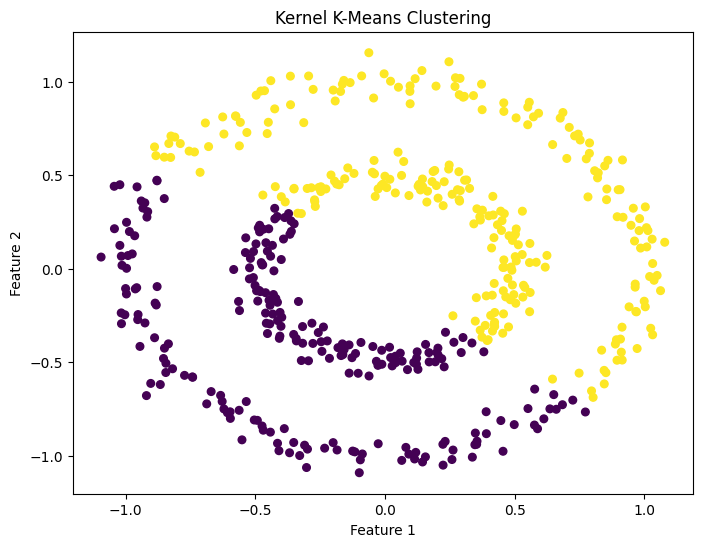

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kernel_labels,
    cmap="viridis",
    s=30
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Kernel K-Means Clustering")

plt.show()

# 14. Ordinary K-Means vs Kernel K-Means

Let's compare the two methods visually.

### Ordinary K-Means

Works directly with:

    X

and uses ordinary Euclidean distance.

### Kernel K-Means

Works implicitly with:

    φ(X)

and uses kernel-based distances.

Therefore, Kernel K-Means can discover cluster structures that are difficult for ordinary K-Means.

For our concentric-circle dataset, this difference is particularly important.

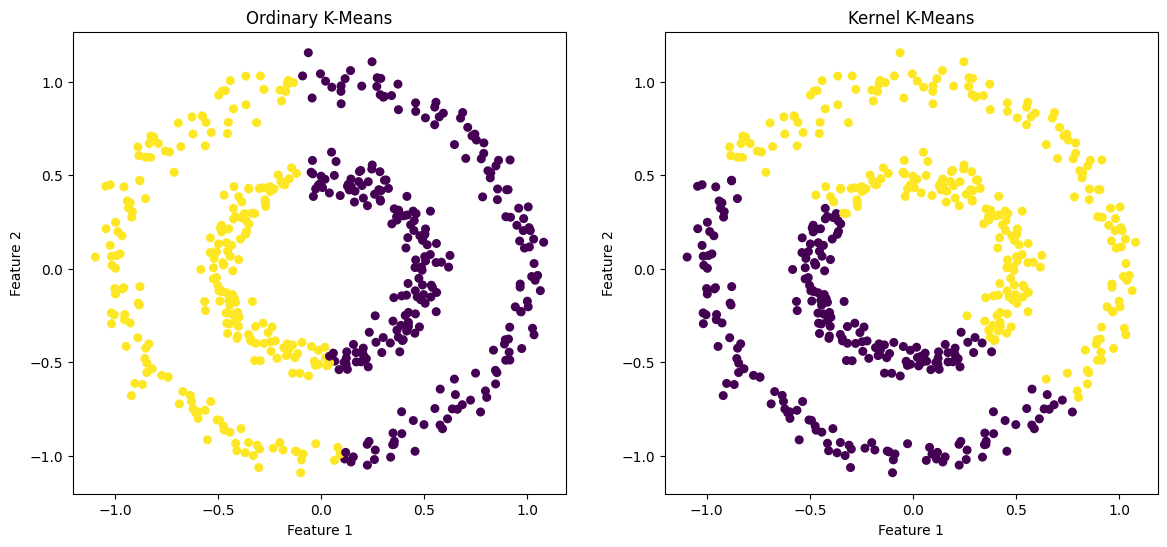

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=30
)

axes[0].set_title("Ordinary K-Means")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")


axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=kernel_labels,
    cmap="viridis",
    s=30
)

axes[1].set_title("Kernel K-Means")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.show()

# 15. Understanding the RBF Kernel

The RBF kernel is:

    K(x,z) = exp(-γ ||x-z||²)

The parameter γ controls how quickly similarity decreases as distance increases.

### Small γ

A small γ produces a slowly decreasing similarity.

Points that are relatively far apart can still have significant similarity.

This creates a smoother and more global notion of similarity.

### Large γ

A large γ causes similarity to decrease rapidly.

Only nearby points have strong similarity.

This creates a more local notion of similarity.

Therefore, γ strongly affects the resulting clusters.

Converged after 4 iterations.
Converged after 8 iterations.
Converged after 9 iterations.
Converged after 12 iterations.


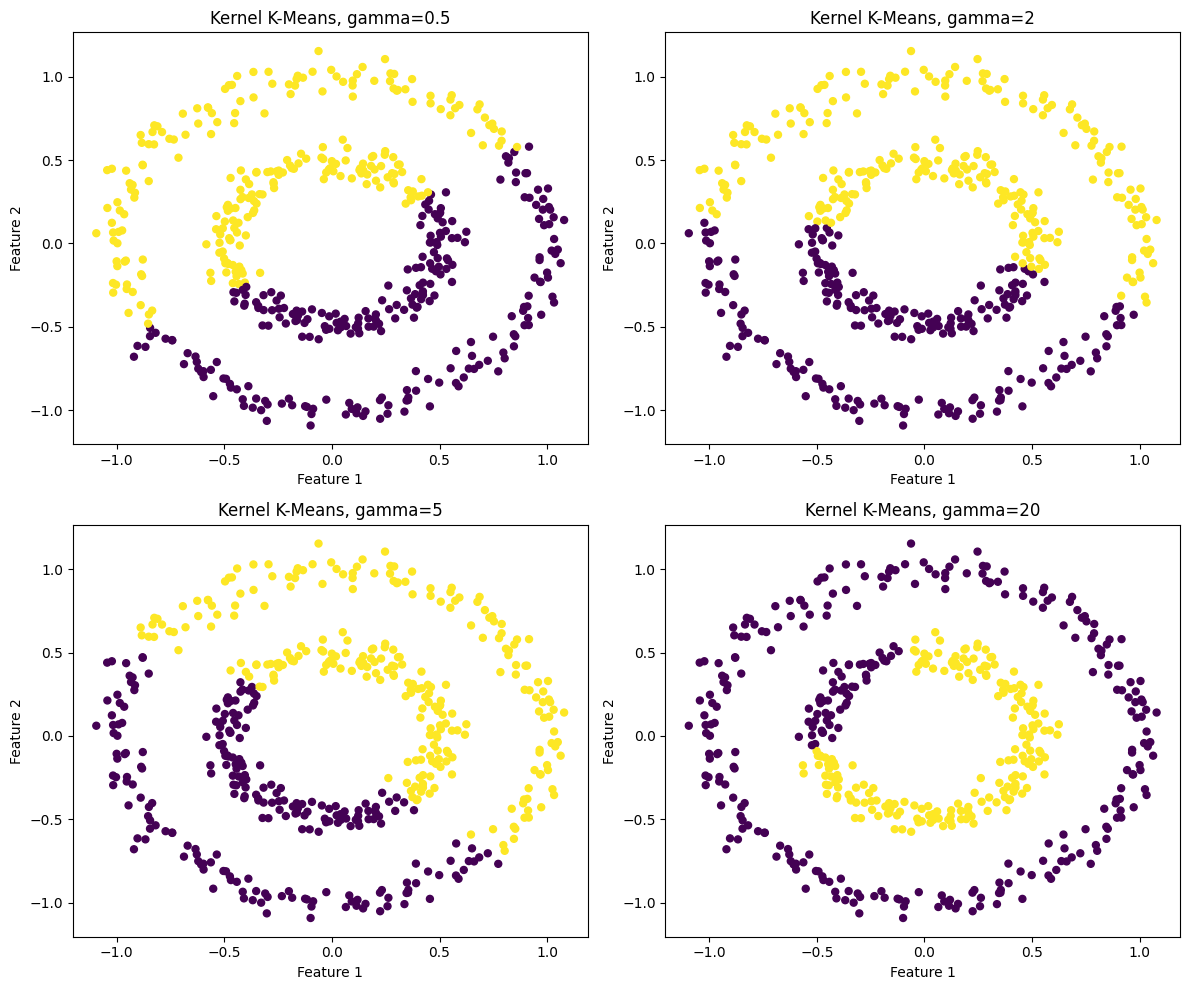

In [21]:
gamma_values = [0.5, 2, 5, 20]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

for ax, gamma in zip(
    axes.ravel(),
    gamma_values
):

    labels, _ = kernel_kmeans(
        X,
        n_clusters=2,
        gamma=gamma,
        max_iter=100,
        random_state=42
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap="viridis",
        s=25
    )

    ax.set_title(
        f"Kernel K-Means, gamma={gamma}"
    )

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# 16. Gamma and Model Complexity

The RBF kernel parameter γ controls the locality of the kernel.

We can think of it approximately as controlling the scale at which points influence one another.

### Low γ

    Broad influence
        ↓
    Smoother similarity structure
        ↓
    Less complex clustering

### High γ

    Local influence
        ↓
    More detailed similarity structure
        ↓
    Potentially more complex clustering

An excessively large γ can make the model sensitive to small local variations.

Therefore, γ is an important hyperparameter.

# 17. Polynomial Kernel

Kernel K-Means is not restricted to the RBF kernel.

We can also use a polynomial kernel:

    K(x,z) = (x · z + c)^d

where:

    d = degree
    c = constant

For example:

    K(x,z) = (x · z + 1)^2

The polynomial kernel allows the algorithm to work with polynomial feature interactions without explicitly constructing all polynomial features.

In [14]:
def polynomial_kernel(
    X,
    degree=2,
    coef0=1
):
    return (
        X @ X.T + coef0
    ) ** degree

In [15]:
K_poly = polynomial_kernel(
    X,
    degree=2,
    coef0=1
)

print(
    "Polynomial kernel matrix shape:",
    K_poly.shape
)

print(
    K_poly[:5, :5]
)

Polynomial kernel matrix shape: (500, 500)
[[1.59863116 1.64924888 1.5017006  1.38374019 2.28816151]
 [1.64924888 3.99717889 1.20361064 0.212735   2.96347774]
 [1.5017006  1.20361064 1.4949159  1.69753527 1.96422326]
 [1.38374019 0.212735   1.69753527 3.5430486  1.35288339]
 [2.28816151 2.96347774 1.96422326 1.35288339 4.14517376]]


# 18. Linear Kernel

The simplest kernel is the linear kernel:

    K(x,z) = x · z

This does not introduce a non-linear transformation.

Therefore, using a linear kernel makes Kernel K-Means much closer to ordinary K-Means in terms of the feature-space geometry.

The main advantage of Kernel K-Means comes from using non-linear kernels such as:

- RBF
- Polynomial
- Sigmoid
- Other valid positive-semidefinite kernels

In [16]:
def linear_kernel(X):
    return X @ X.T


K_linear = linear_kernel(X)

print("Linear kernel matrix shape:", K_linear.shape)

Linear kernel matrix shape: (500, 500)


# 19. Important Hyperparameters

Kernel K-Means has several important choices.

## Number of clusters

    n_clusters

This determines K.

Example:

    K = 2

means that we want two clusters.

---

## Kernel Type

Examples:

    Linear
    Polynomial
    RBF

---

## Gamma

For the RBF kernel:

    γ

controls the locality of similarity.

---

## Maximum Iterations

Controls how many times the algorithm can update cluster assignments.

---

## Initialization

Kernel K-Means can be sensitive to initialization, just like ordinary K-Means.

Different initial assignments can sometimes produce different solutions.

# 20. Advantages of Kernel K-Means

### 1. Handles Non-Linear Structures

Kernel K-Means can identify clusters that are difficult to detect using ordinary K-Means.

### 2. Uses the Kernel Trick

It can work in a high-dimensional feature space without explicitly constructing that space.

### 3. Flexible

Different kernels can represent different notions of similarity.

### 4. Useful for Complex Data

It can be useful when the cluster structure is strongly non-linear.

# 21. Limitations of Kernel K-Means

Kernel K-Means also has important limitations.

### 1. Computational Cost

The kernel matrix has size:

    n × n

For n data points, storing it requires approximately:

    O(n²)

memory.

This can become expensive for large datasets.

---

### 2. Kernel Selection

Choosing an appropriate kernel can be difficult.

---

### 3. Hyperparameter Selection

Parameters such as γ can strongly affect the clustering result.

---

### 4. Initialization Sensitivity

Different initial cluster assignments can produce different solutions.

---

### 5. Number of Clusters Must Be Selected

Like ordinary K-Means, Kernel K-Means requires the number of clusters K to be specified.

# 22. Kernel K-Means vs Ordinary K-Means

| Property | Ordinary K-Means | Kernel K-Means |
|---|---|---|
| Feature space | Original space | Implicit feature space |
| Distance | Euclidean | Kernel-based |
| Handles non-linear clusters | Limited | Yes |
| Kernel required | No | Yes |
| Explicit centroid | Yes | No |
| Kernel matrix | No | Yes |
| Memory requirement | Lower | Higher |
| Hyperparameters | Relatively simple | More complex |
| Large datasets | Generally easier | Can become expensive |

### Key difference

Ordinary K-Means:

    Cluster X

Kernel K-Means:

    Cluster φ(X)

without explicitly calculating φ(X).

# 23. Kernel K-Means Intuition

The entire idea can be summarized as:

    Original Data
          |
          v
    Choose a Kernel
          |
          v
    Kernel Matrix
          |
          v
    Similarity in Feature Space
          |
          v
    Kernel-Space Distances
          |
          v
    Cluster Assignment
          |
          v
    Repeat Until Convergence

The kernel allows us to change the geometry of the problem.

This is why Kernel K-Means can discover non-linear cluster structures.

# 24. Practical Interpretation

Suppose we have customer data.

Ordinary K-Means may assume that customers form simple groups based on Euclidean distance.

However, customer behavior may contain complex relationships.

A kernel can provide a different similarity measure.

Instead of asking only:

    "How close are these two customers
     in the original feature space?"

we can ask:

    "How similar are these two customers
     according to the chosen kernel?"

Kernel K-Means then clusters customers according to this kernel-induced similarity structure.

# 25. Important Conceptual Distinction

Kernel K-Means should not be confused with:

- Kernel PCA
- Support Vector Machines
- Spectral Clustering
- Ordinary K-Means

They all use related kernel ideas in some settings, but they solve different problems.

### K-Means

Unsupervised clustering.

### Kernel K-Means

Non-linear unsupervised clustering using a kernel.

### Kernel PCA

Non-linear dimensionality reduction.

### SVM

Supervised classification or regression.

### Spectral Clustering

Graph/similarity-based clustering using eigenvectors of a matrix.

Understanding this distinction is important.

# 26. Final Summary

Kernel K-Means extends K-Means to non-linear feature spaces.

The central idea is:

    x → φ(x)

Instead of explicitly calculating φ(x), we use a kernel:

    K(x,z) = φ(x) · φ(z)

The kernel matrix contains pairwise similarities:

    Kᵢⱼ = K(xᵢ,xⱼ)

Kernel-space distances can then be calculated using the kernel matrix.

For the RBF kernel:

    K(x,z) =
    exp(-γ ||x-z||²)

The main advantages are:

- Ability to model non-linear cluster structures.
- Flexible similarity functions.
- No need to explicitly construct the high-dimensional feature space.

The main disadvantages are:

- O(n²) kernel matrix storage.
- Higher computational cost.
- Kernel and hyperparameter selection.
- Sensitivity to initialization.

### Most important takeaway

Ordinary K-Means clusters points using geometry in the original feature space.

Kernel K-Means changes the geometry using a kernel and performs clustering in an implicit feature space.

# 27. Key Formulas

### Ordinary K-Means

Centroid:

    μₖ = (1 / |Cₖ|) Σᵢ∈Cₖ xᵢ

Objective:

    J = Σᵢ ||xᵢ - μ_cᵢ||²


### Kernel Function

    K(x,z) = φ(x) · φ(z)


### RBF Kernel

    K(x,z) =
    exp(-γ ||x-z||²)


### Kernel-Space Distance

    ||φ(xᵢ) - φ(xⱼ)||²

    =
    Kᵢᵢ + Kⱼⱼ - 2Kᵢⱼ


### Distance from Point to Kernel Cluster

    D(i,C)
    =
    Kᵢᵢ
    - (2 / |C|) Σⱼ∈C Kᵢⱼ
    + (1 / |C|²) Σⱼ∈C Σₗ∈C Kⱼₗ